In [5]:
# ==========================================
# CELL 1: SETUP & METRICS ENGINE
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# Set global plot styling for publication-ready thesis figures
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--'
})

def calculate_validation_metrics(observed, simulated):
    """
    Calculates R2, RMSE, MAE, and Bias between observed and simulated datasets.
    Automatically handles missing (NaN) values.
    """
    # Create a temporary dataframe to easily drop missing values in pairs
    temp_df = pd.DataFrame({'obs': observed, 'sim': simulated}).dropna()
    obs = temp_df['obs']
    sim = temp_df['sim']
    
    if len(obs) == 0:
        return {"R2": np.nan, "RMSE": np.nan, "MAE": np.nan, "Bias": np.nan}
    
    # Calculate Metrics
    r, _ = pearsonr(obs, sim)
    r2 = r**2
    rmse = np.sqrt(mean_squared_error(obs, sim))
    mae = mean_absolute_error(obs, sim)
    bias = np.mean(sim) - np.mean(obs)
    
    return {
        "R2": round(r2, 3), 
        "RMSE": round(rmse, 2), 
        "MAE": round(mae, 2), 
        "Bias": round(bias, 2)
    }

print("Cell 1 Executed: Libraries loaded and Metrics Engine ready.")

Cell 1 Executed: Libraries loaded and Metrics Engine ready.


In [31]:
# ==========================================
# CELL 2: STRICT MONTHLY ALIGNMENT & METRICS (WITH CMIP6 UNIT FIX)
# ==========================================
import pandas as pd
import numpy as np
import xarray as xr
import os

base_dir = r"C:\Users\Baikania Amonison\Desktop\final data extraction and analysis"

# ---------------------------------------------------------
# 1. LOAD & AGGREGATE OBSERVED DATA
# ---------------------------------------------------------
obs_path = os.path.join(base_dir, "Observed_Rainfall_1981_2014.csv")
df_obs_raw = pd.read_csv(obs_path, skiprows=[1, 2], low_memory=False)
df_obs_raw['Date'] = pd.to_datetime(df_obs_raw['ID'], format='%Y%m%d')

station_columns = df_obs_raw.columns.drop(['ID', 'Date'])
df_obs_raw[station_columns] = df_obs_raw[station_columns].astype(float)

df_obs_raw['Daily_Basin_Avg_mm'] = df_obs_raw[station_columns].mean(axis=1)

df_obs_monthly = df_obs_raw[['Date', 'Daily_Basin_Avg_mm']].set_index('Date').resample('MS').sum().reset_index()
df_obs_monthly.rename(columns={'Daily_Basin_Avg_mm': 'Observed_mm'}, inplace=True)
df_obs_monthly['Month'] = df_obs_monthly['Date'].dt.to_period('M')

# ---------------------------------------------------------
# 2. LOAD & AGGREGATE CHIRPS DATA
# ---------------------------------------------------------
chirps_path = os.path.join(base_dir, "Nyabarongo_CHIRPS_Cleaned_1981_2014.csv")
df_chirps = pd.read_csv(chirps_path)
df_chirps['Date'] = pd.to_datetime(df_chirps['Date'])

df_chirps_monthly = df_chirps[['Date', 'Rainfall_avg_mm']].set_index('Date').resample('MS').sum().reset_index()
df_chirps_monthly['Month'] = df_chirps_monthly['Date'].dt.to_period('M')

# ---------------------------------------------------------
# 3. LOAD & AGGREGATE ACCESS-CM2 DATA
# ---------------------------------------------------------
cmip6_path = os.path.join(base_dir, "Nyabarongo_pr_historical_aggregated.nc")
ds_cmip6 = xr.open_dataset(cmip6_path)

spatial_dims = [dim for dim in ds_cmip6.dims if dim != 'time']
if spatial_dims:
    ds_cmip6 = ds_cmip6.mean(dim=spatial_dims)

cmip6_series = ds_cmip6['pr'].to_dataframe().reset_index()
cmip6_series['time'] = pd.to_datetime(cmip6_series['time']).dt.tz_localize(None)

# --- THE FIX: Convert from mm/s to mm/day ---
cmip6_series['pr_mm_day'] = cmip6_series['pr'] * 86400

# Now sum the correct mm/day values into monthly totals
cmip6_monthly = cmip6_series[['time', 'pr_mm_day']].set_index('time').resample('MS').sum().reset_index()
cmip6_monthly.rename(columns={'pr_mm_day': 'ACCESS_mm'}, inplace=True)
cmip6_monthly['Month'] = cmip6_monthly['time'].dt.to_period('M')

# ---------------------------------------------------------
# 4. FINAL ALIGNMENT & METRICS CALCULATION
# ---------------------------------------------------------
obs_data = df_obs_monthly.set_index('Month')['Observed_mm']
chirps_data = df_chirps_monthly.set_index('Month')['Rainfall_avg_mm']
access_data = cmip6_monthly.set_index('Month')['ACCESS_mm']

start_month = pd.Period('1981-01', 'M')
end_month = pd.Period('2014-12', 'M')

obs_data = obs_data[(obs_data.index >= start_month) & (obs_data.index <= end_month)]
chirps_data = chirps_data[(chirps_data.index >= start_month) & (chirps_data.index <= end_month)]
access_data = access_data[(access_data.index >= start_month) & (access_data.index <= end_month)]

if len(obs_data) == len(chirps_data) == len(access_data) == 408:
    print("\nSUCCESS: All datasets successfully aggregated and synchronized (408 months).")
    
    print("\n--- Validation Summary Table ---")
    metrics_chirps = calculate_validation_metrics(obs_data, chirps_data)
    metrics_access = calculate_validation_metrics(obs_data, access_data)

    summary_table = pd.DataFrame([metrics_chirps, metrics_access], index=['CHIRPS', 'ACCESS-CM2'])
    display(summary_table)
else:
    print("\nWARNING: Timeline lengths do not match.")


SUCCESS: All datasets successfully aggregated and synchronized (408 months).

--- Validation Summary Table ---


,R2,RMSE,MAE,Bias
CHIRPS,0.827,28.91,20.15,-14.33
ACCESS-CM2,0.323,54.78,43.06,-9.52


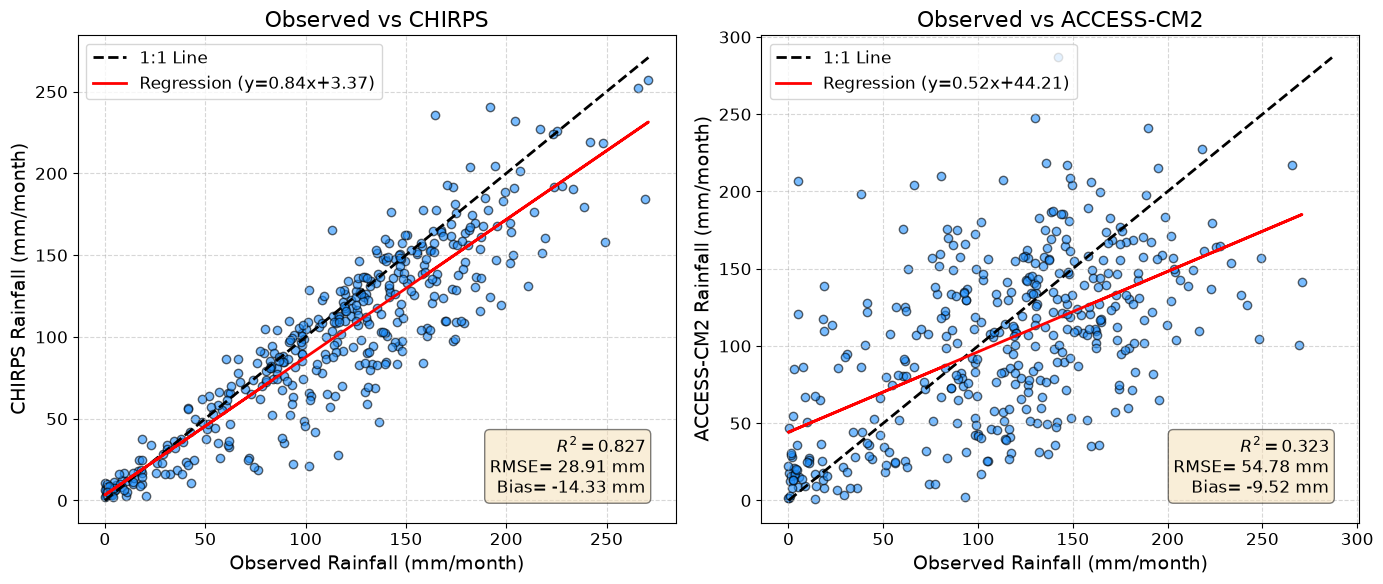

In [32]:
# ==========================================
# CELL 3: 1:1 SCATTER PLOTS
# ==========================================

def plot_validation_scatter(obs, sim, model_name, ax, metrics):
    """Generates a single 1:1 scatter plot with metrics annotated."""
    # Scatter points
    ax.scatter(obs, sim, alpha=0.6, edgecolors='k', color='dodgerblue')
    
    # 1:1 Line (Perfect Fit)
    min_val = min(obs.min(), sim.min())
    max_val = max(obs.max(), sim.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='1:1 Line')
    
    # Regression Line
    m, b = np.polyfit(obs, sim, 1)
    ax.plot(obs, m*obs + b, 'r-', lw=2, label=f'Regression (y={m:.2f}x+{b:.2f})')
    
    # Formatting
    ax.set_xlabel('Observed Rainfall (mm/month)')
    ax.set_ylabel(f'{model_name} Rainfall (mm/month)')
    ax.set_title(f'Observed vs {model_name}')
    ax.legend(loc='upper left')
    
    # Annotate Metrics Box
    textstr = '\n'.join((
        f'$R^2= {metrics["R2"]}$',
        f'RMSE= {metrics["RMSE"]} mm',
        f'Bias= {metrics["Bias"]} mm'))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.95, 0.05, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_validation_scatter(obs_data, chirps_data, "CHIRPS", ax1, metrics_chirps)
plot_validation_scatter(obs_data, access_data, "ACCESS-CM2", ax2, metrics_access)

plt.tight_layout()
plt.show()

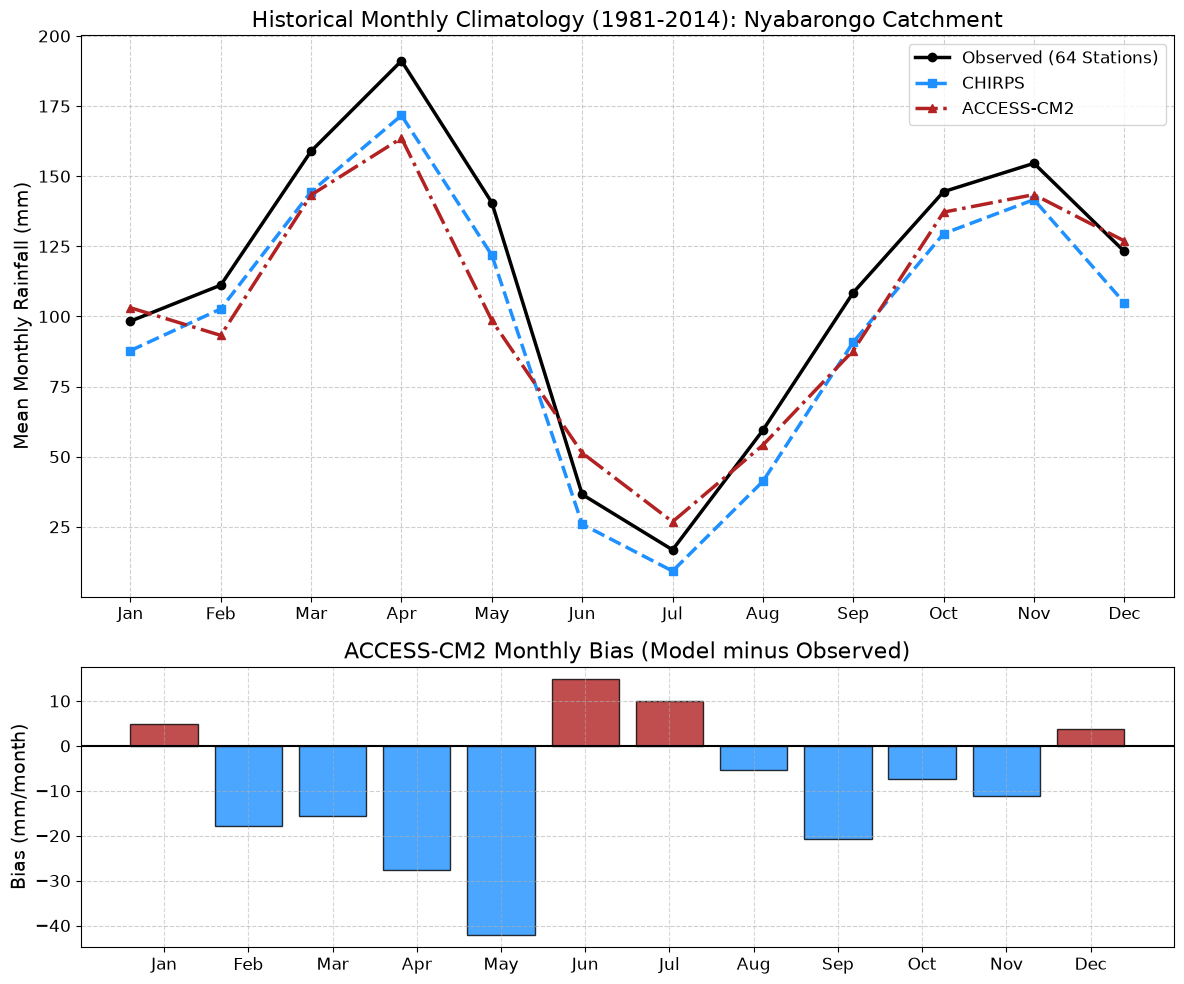

In [33]:
# ==========================================
# CELL 4: MONTHLY CLIMATOLOGY & BIAS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Group by calendar month (1 to 12) to calculate the 34-year average for each month
obs_monthly = obs_data.groupby(obs_data.index.month).mean()
chirps_monthly = chirps_data.groupby(chirps_data.index.month).mean()
access_monthly = access_data.groupby(access_data.index.month).mean()

# Calculate Bias for the bar chart (Model minus Observed)
bias_monthly = access_monthly - obs_monthly

# Define the x-axis labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 2. Set up the plotting area (2 subplots stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Subplot 1: Climatology Lines ---
# We use .values to ensure the plotting function aligns the data strictly with the 'months' labels
ax1.plot(months, obs_monthly.values, marker='o', linewidth=2.5, color='black', label='Observed (64 Stations)')
ax1.plot(months, chirps_monthly.values, marker='s', linewidth=2.5, color='dodgerblue', linestyle='--', label='CHIRPS')
ax1.plot(months, access_monthly.values, marker='^', linewidth=2.5, color='firebrick', linestyle='-.', label='ACCESS-CM2')

ax1.set_ylabel('Mean Monthly Rainfall (mm)')
ax1.set_title('Historical Monthly Climatology (1981-2014): Nyabarongo Catchment')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Subplot 2: Bias Bar Chart ---
# Automatically color bars: Red for overestimation, Blue for underestimation
colors = ['firebrick' if val > 0 else 'dodgerblue' for val in bias_monthly.values]
ax2.bar(months, bias_monthly.values, color=colors, alpha=0.8, edgecolor='black')

ax2.axhline(0, color='black', linewidth=1.5)
ax2.set_ylabel('Bias (mm/month)')
ax2.set_title('ACCESS-CM2 Monthly Bias (Model minus Observed)')
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [34]:
# Save the Validation Summary Table for Chapter 4
output_table_path = os.path.join(base_dir, "Validation_Summary_Table.csv")
summary_table.to_csv(output_table_path)

print(f"Summary table successfully saved to: {output_table_path}")

Summary table successfully saved to: C:\Users\Baikania Amonison\Desktop\final data extraction and analysis\Validation_Summary_Table.csv
